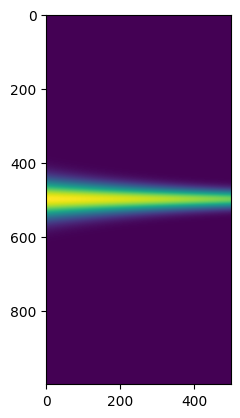

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
L = 10.0  # Domain length
T = 10.0  # Total time
A = -0.1   # Drift coefficient
B = 0.1   # Diffusion coefficient

# Discretization parameters
N_x = 1000  # Number of spatial points
dx = 2 * L / (N_x - 1)  # Spatial step size

# Initial condition: Gaussian centered at x=0
x = np.linspace(-L, L, N_x)
P0 = np.exp(-x**2) / np.sqrt(np.pi)


# Fokker plank for SDE dX = Ax dt + B dWt
# ODE system
def fokker_planck_odes(t, P):
    dPdt = np.zeros_like(P)
    dPdt[1:-1] = -A * x[1:-1] * (P[2:] - P[:-2]) / (2 * dx) + (B**2 / 2) * (P[2:] - 2 * P[1:-1] + P[:-2]) / dx**2
    return dPdt

# Time points for evaluation
t_eval = np.linspace(0, T, 500)

# Solve the ODE system
solution = solve_ivp(fokker_planck_odes, [0, T], P0, t_eval=t_eval, method='RK45')

# Plot the results
plt.imshow(solution.y)

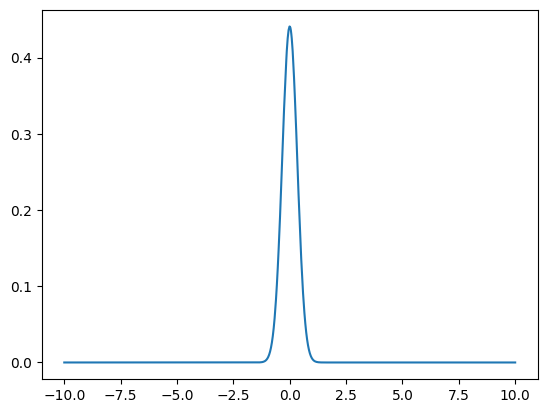

In [64]:
plt.plot(x, solution.y[:, -1], label='t=0')